In [3]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#loading dataset
file_path = '/Users/prosas/Documents/SQL_Stuff/all_folders/project_sql/2_top_paying_job_skills.csv'
dataset = pd.read_csv(file_path)
dataset

,job_id,job_title,job_title_short,company_name,salary_year_avg,job_skills
0,226942,Data Analyst,Data Analyst,Mantys,650000.0,NaN
1,547382,Director of Analytics,Data Analyst,Meta,336500.0,NaN
2,552322,Associate Director- Data Insights,Data Analyst,AT&T,255829.5,pyspark
3,552322,Associate Director- Data Insights,Data Analyst,AT&T,255829.5,powerpoint
4,552322,Associate Director- Data Insights,Data Analyst,AT&T,255829.5,power bi
...,...,...,...,...,...,...
2555,1178688,Data Analyst,Data Analyst,Jobmatchingpartner Ltd,35000.0,python
2556,1178688,Data Analyst,Data Analyst,Jobmatchingpartner Ltd,35000.0,r
2557,1178688,Data Analyst,Data Analyst,Jobmatchingpartner Ltd,35000.0,spark
2558,1178688,Data Analyst,Data Analyst,Jobmatchingpartner Ltd,35000.0,hadoop


In [17]:
df = dataset.copy()
df_skills_salary = df.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False) 
df_count = len(df)
df_skills_salary = df_skills_salary.rename(columns={'count':'skill_count', 'median':'median_salary'}) #renamed columns to avoid confusion
df_skills_salary['skills_percent'] = (df_skills_salary['skill_count'] / df_count) * 100
df_skills_salary = df_skills_salary.head(10)
df_skills_salary



,skill_count,median_salary,skills_percent
job_skills,,,
sql,398,90000.0,15.546875
excel,256,82500.0,10.000000
python,236,95000.0,9.218750
tableau,230,92625.0,8.984375
r,148,90000.0,5.781250
sas,126,95000.0,4.921875
power bi,110,95000.0,4.296875
powerpoint,58,85000.0,2.265625
looker,49,95000.0,1.914063


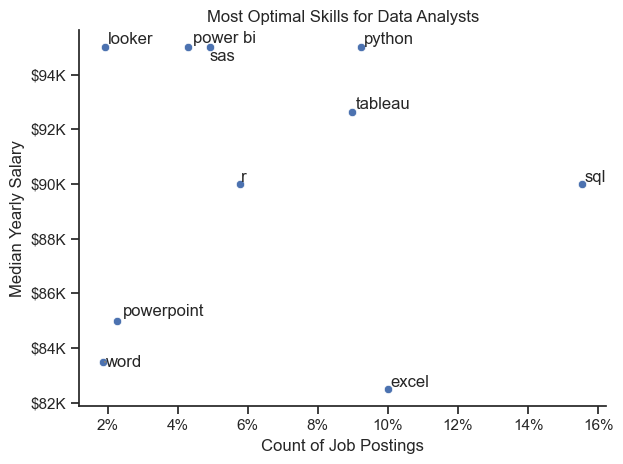

In [24]:
from adjustText import adjust_text
sns.scatterplot(
    data=df_skills_salary, 
    x='skills_percent',
    y='median_salary',
    )
sns.set_theme(style='ticks')
sns.despine()
texts = []
for i, txt in enumerate(df_skills_salary.index):
    if i == 5: ##this was done due to powerBI and sas texts were overlapping
        texts.append(plt.text(df_skills_salary['skills_percent'].iloc[i], df_skills_salary['median_salary'].iloc[i]-1, txt))
    else:
        texts.append(plt.text(df_skills_salary['skills_percent'].iloc[i], df_skills_salary['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color = 'gray', lw=1))
ax = plt.gca() #allows you to get the current axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')) #we grab the y-axis and apply a function to format the numbers
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0f}%'))


plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts')
plt.tight_layout()
plt.show()